## Problem

You have a list of locations in geographic coordinates and want to get the closest values to those locations from a gridded data product

In [ ]:
# Generate dummy data
import numpy as np
import datetime as dt
# import pandas as pd

n_points = 50

# generate Arctic points (lat > 60)
points = []
while len(points) < n_points:
    batch = 500
    lat = np.degrees(np.arcsin(np.random.uniform(-1, 1, batch)))
    lon = np.random.uniform(-180, 180, batch)

    mask = lat > 75
    for la, lo in zip(lat[mask], lon[mask]):
        points.append((la, lo))
        if len(points) >= n_points:
            break

lat, lon = np.array(points).T

# random dates after Oct 2018

start_date = dt.datetime(2018, 10, 1)
end_date = dt.datetime.now()
ndays = (end_date - start_date).days
incr = np.random.choice(np.arange(0,ndays), 50)
days = [start_date + dt.timedelta(days=int(i)) for i in incr]

## Solution

We'll use `earthaccess` to select the data granules, and `geopandas` and `xarray` extract the points.

We use a `geopandas.GeoDataFrame` to store the data points because it has a convenient method to transform coordinate systems.

We use `xarray` [vectorized indexing](https://tutorial.xarray.dev/intermediate/indexing/advanced-indexing.html) to select the grid values corresponding to each point.

_Standard "orthogonal" indexing returns a 2D grid rather than a 1D list of values._

### Get data

In [64]:
import earthaccess

auth = earthaccess.login()

results = earthaccess.search_data(
    short_name='ATL21',
    temporal=(min(days), max(days)),
)

# Filter results on date
len(results)

420

In [129]:
results[0]['umm']['SpatialExtent']

{'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -179.999996,
     'EastBoundingCoordinate': 179.999996,
     'NorthBoundingCoordinate': 88.045543,
     'SouthBoundingCoordinate': 66.163953}]}}}

In [130]:
results[0]['umm']['TemporalExtent']

{'RangeDateTime': {'BeginningDateTime': '2018-10-14T00:21:48.736Z',
  'EndingDateTime': '2018-10-31T23:05:09.137Z'}}

Could use Luis's `virtualizarr` here to lazy-load data cube.  For now just download data.

In [65]:
import xarray as xr
import rioxarray

# files = earthaccess.open(results)
files = earthaccess.download(results[0], local_path='data')

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [110]:
ds = xr.open_datatree(
    files[0], 
    decode_timedelta=False, 
    decode_coords='all',
)
crs = ds.crs
ds = ds["monthly"].to_dataset(inherit='all_coordinates')  # Just get monthly grids
ds = ds.rename({'grid_x': 'x', 'grid_y': 'y', })
ds["crs"] = crs
ds

/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['../../crs']
  ds = xr.open_datatree(
/tmp/ipykernel_464073/2602607402.py:1: UserWarning: Variable(s) referenced in grid_mapping not in variables: ['.

<xarray.Dataset> Size: 4MB
Dimensions:                        (phony_dim_25: 1, y: 448, x: 304,
                                    phony_dim_27: 1)
Coordinates:
  * y                              (y) float64 4kB 5.838e+06 ... -5.338e+06
  * x                              (x) float64 2kB -3.838e+06 ... 3.738e+06
Dimensions without coordinates: phony_dim_25, phony_dim_27
Data variables:
    delta_time_beg                 (phony_dim_25) datetime64[ns] 8B ...
    delta_time_end                 (phony_dim_25) datetime64[ns] 8B ...
    mean_ssha                      (y, x) float32 545kB ...
    mean_weighted_earth_free2mean  (y, x) float32 545kB ...
    mean_weighted_geoid            (y, x) float32 545kB ...
    mean_weighted_geoid_free2mean  (y, x) float32 545kB ...
    mean_weighted_mss              (y, x) float32 545kB ...
    n_refsurfs                     (y, x) float64 1MB ...
    sigma                          (y, x) float32 545kB ...
    crs                            (phony_dim_27) int8 1B ...
Attributes:
    Description:  Gridded Monthly averages

In [125]:
ds.delta_time_beg.values

array(['2018-10-14T00:21:49.440616236'], dtype='datetime64[ns]')

### Use `geopandas` to transform geographic coordinates to grid CRS

We assume that the original geographic coordinates are in WGS84.  Geopandas offers a convenient way to transform the coordinates and also to export transformed coordinates to `xarray.DataArray` objects.

_This could be done using `pyproj` as well, but `geopandas` is convenient._

In [111]:
import pandas as pd
import geopandas as gpd

# gdf = gpd.GeoDataFrame
df = pd.DataFrame({
    'latitude': lat, 
    'longitude': lon, 
    'date': days,
})
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(lon, lat), crs="EPSG:4326")

In [112]:
gdf

,latitude,longitude,date,geometry
0,85.878887,-99.876421,2025-12-02,POINT (-99.87642 85.87889)
1,82.540094,-110.356676,2023-09-30,POINT (-110.35668 82.54009)
2,77.002147,-106.509007,2021-12-13,POINT (-106.50901 77.00215)
3,82.242096,-166.134799,2020-02-06,POINT (-166.1348 82.2421)
4,81.609988,-84.541883,2019-11-14,POINT (-84.54188 81.60999)
5,77.161087,-32.784409,2024-09-20,POINT (-32.78441 77.16109)
6,82.406983,129.734214,2024-03-30,POINT (129.73421 82.40698)
7,76.306542,-98.611666,2023-11-05,POINT (-98.61167 76.30654)
8,84.732205,-84.142686,2024-08-15,POINT (-84.14269 84.7322)
9,84.878425,-25.139996,2020-04-12,POINT (-25.14 84.87843)


<GeoAxes: xlabel='gridded x [meters]', ylabel='gridded y [meters]'>

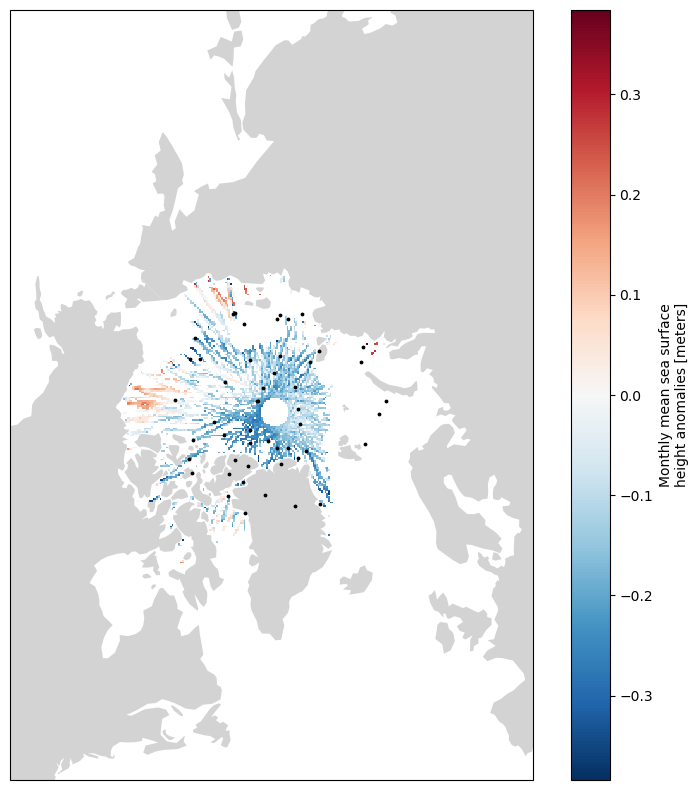

In [114]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

globe = ccrs.Globe(
    ellipse=None, 
    semimajor_axis=ds.crs.semi_major_axis, 
    inverse_flattening=ds.crs.inverse_flattening
)
projection = ccrs.Stereographic(
    central_latitude=ds.crs.latitude_of_projection_origin, 
    central_longitude=ds.crs.longitude_of_projection_origin,
    true_scale_latitude=ds.crs.standard_parallel,
)

p = ds.mean_ssha.plot(
    subplot_kws=dict(projection=projection),
    figsize=(10,10)
)
p.axes.add_feature(cfeature.LAND, facecolor='lightgrey')
gdf.to_crs(3411).plot(ax=p.axes, markersize=3, color='black')

### Create xarray containing points

In [99]:
pts_xr = gdf.to_crs(3411).geometry.get_coordinates().to_xarray()
pts_xr

<xarray.Dataset> Size: 1kB
Dimensions:  (index: 50)
Coordinates:
  * index    (index) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
Data variables:
    x        (index) float64 400B -3.653e+05 -7.355e+05 ... -1.45e+06 -9.672e+04
    y        (index) float64 400B -2.57e+05 -3.374e+05 ... 1.734e+05 -4.166e+05

In [116]:
ds.mean_ssha.sel(x=pts_xr.x, y=pts_xr.y, method='nearest')

<xarray.DataArray 'mean_ssha' (index: 50)> Size: 200B
[50 values with dtype=float32]
Coordinates:
  * index    (index) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
    x        (index) float64 400B -3.625e+05 -7.375e+05 ... -1.438e+06 -8.75e+04
    y        (index) float64 400B -2.625e+05 -3.375e+05 ... 1.625e+05 -4.125e+05
Attributes:
    long_name:    Monthly mean sea surface height anomalies
    units:        meters
    source:       Sea Ice ATBD
    contentType:  modelResult
    description:  Monthly mean sea surface height anomalies (SSHA) for each m...